## 📊 A— Correlação

### Explicação  da Teoria
A **Regressão Linear** busca encontrar a melhor reta ($y = ax + b$) que descreve a relação entre duas variáveis. 

* **`scipy.stats.linregress`**: Função que utiliza o método dos mínimos quadrados. Ela retorna:
    * **Coeficiente Angular ($a$)**: Inclinação da reta. Indica a taxa de variação de $y$ em relação a $x$.
    * **Intercepto ($b$)**: Onde a reta cruza o eixo $y$.
    * **p-value**: Testa a hipótese nula de que a inclinação é zero ($a=0$). Se $p < 0.05$, rejeitamos a hipótese nula, indicando uma relação estatisticamente significativa.
* **Covariância**: Mede a variância conjunta de duas variáveis. Se for positiva, ambas tendem a crescer juntas.

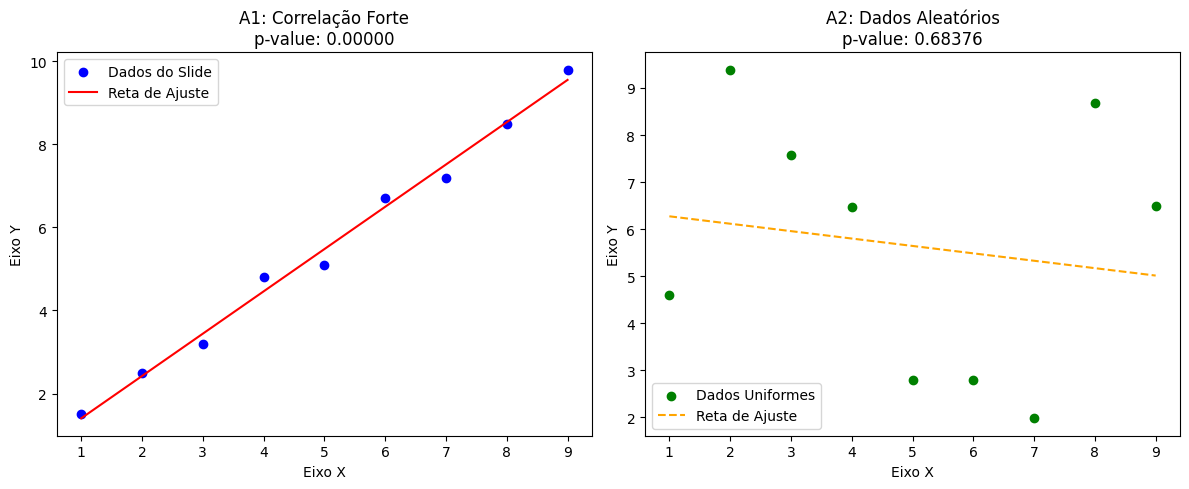

Covariância A1: 7.64
Covariância A2: -1.18


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

#GRÁFICO 1
x1 = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9])
y1 = np.array([1.5, 2.5, 3.2, 4.8, 5.1, 6.7, 7.2, 8.5, 9.8]) # Correlação forte

#GRAFICO 2: DADOS ALEATÓRIOS 
np.random.seed(42) 
x2 = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9])
y2 = np.random.uniform(low=min(y1), high=max(y1), size=9)

#calculos via linregress
slope1, intercept1, r1, p1, std_err1 = stats.linregress(x1, y1)
slope2, intercept2, r2, p2, std_err2 = stats.linregress(x2, y2)

#calculo da covariancia
cov1 = np.cov(x1, y1)[0, 1]
cov2 = np.cov(x2, y2)[0, 1]

#plotagem
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1
ax1.scatter(x1, y1, color='blue', label='Dados do Slide')
ax1.plot(x1, slope1*x1 + intercept1, color='red', label='Reta de Ajuste')
ax1.set_title(f"A1: Correlação Forte\np-value: {p1:.5f}")
ax1.set_xlabel("Eixo X"); ax1.set_ylabel("Eixo Y"); ax1.legend()

#plot 2
ax2.scatter(x2, y2, color='green', label='Dados Uniformes')
ax2.plot(x2, slope2*x2 + intercept2, color='orange', linestyle='--', label='Reta de Ajuste')
ax2.set_title(f"A2: Dados Aleatórios\np-value: {p2:.5f}")
ax2.set_xlabel("Eixo X"); ax2.set_ylabel("Eixo Y"); ax2.legend()

plt.tight_layout()
plt.show()

print(f"Covariância A1: {cov1:.2f}")
print(f"Covariância A2: {cov2:.2f}")

## 📈 B — Estimando um Intervalo de Confiança para a Média

### Definição e Interpretação
O **Intervalo de Confiança (IC)** é um intervalo estimado onde a média real da população deve estar, com uma determinada probabilidade.

**Fórmula utilizada:**
$$IC = \bar{x} \pm t_{\alpha/2} \cdot \left(\frac{s}{\sqrt{n}}\right)$$

* **Comparação entre níveis:** * Um **IC de 99%** é mais largo que um de **90%**, pois para aumentar a certeza de que o valor real está no intervalo, precisamos aumentar a margem de erro.

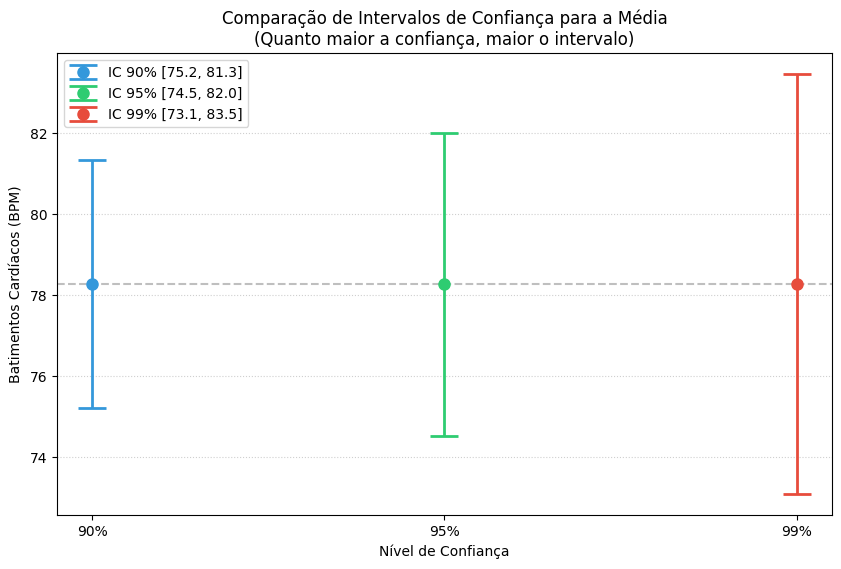

Média Amostral: 78.27
IC 90%: 75.19 até 81.34
IC 95%: 74.53 até 82.01
IC 99%: 73.07 até 83.46


In [50]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

dados = np.array([85, 71, 78, 92, 69, 75, 80, 88, 72, 79, 81, 74, 83, 70, 77])

media = np.mean(dados)
std_err = st.sem(dados) #erro padrao da media
n = len(dados)

#niveis de confianca solicitados
niveis = [0.90, 0.95, 0.99]
cores = ['#3498db', '#2ecc71', '#e74c3c'] # Cores acadêmicas

plt.figure(figsize=(10, 6))

#gera intervalos e plota
for i, conf in enumerate(niveis):
    intervalo = st.t.interval(conf, df=n-1, loc=media, scale=std_err)
    margem = intervalo[1] - media
    
    #plotagem com erro
    plt.errorbar(i, media, yerr=[[margem], [margem]], fmt='o', color=cores[i], 
                 capsize=10, capthick=2, elinewidth=2, markersize=8,
                 label=f'IC {int(conf*100)}% [{intervalo[0]:.1f}, {intervalo[1]:.1f}]')

plt.axhline(media, color='gray', linestyle='--', alpha=0.5) # Linha da média central
plt.xticks(range(len(niveis)), ['90%', '95%', '99%'])
plt.title('Comparação de Intervalos de Confiança para a Média\n(Quanto maior a confiança, maior o intervalo)', fontsize=12)
plt.ylabel('Batimentos Cardíacos (BPM)')
plt.xlabel('Nível de Confiança')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend()

plt.show()

#exibicao dos valores para interpretacao teorica
print(f"Média Amostral: {media:.2f}")
for conf in niveis:
    inter = st.t.interval(conf, df=n-1, loc=media, scale=std_err)
    print(f"IC {int(conf*100)}%: {inter[0]:.2f} até {inter[1]:.2f}")

## 🧪 C — p-value em um Teste de Hipótese

### Metodologia
* **Hipótese Nula ($H_0$):** Não existe diferença significativa entre as médias do Grupo Controle e do Grupo Teste.
* **Hipótese Alternativa ($H_1$):** Existe uma diferença significativa.

O **p-value** indica a probabilidade de observar os resultados obtidos (ou algo mais extremo) assumindo que $H_0$ é verdadeira. Se $p < 0.05$, o resultado é considerado improvável de ter ocorrido por acaso, logo, rejeitamos $H_0$.

In [51]:
 # Dados simulados (Ex: Notas de alunos com e sem monitoria)
controle = np.random.normal(7.0, 1.0, 30)
teste = np.random.normal(7.8, 1.0, 30)

t_stat, p_val = st.ttest_ind(controle, teste)

print(f"Estatística T: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")

alpha = 0.05
if p_val < alpha:
    print("Resultado: Rejeitamos a hipótese nula (H0). Há diferença significativa.")
else:
    print("Resultado: Não há evidências para rejeitar H0.")

Estatística T: -4.4412
p-value: 0.0000
Resultado: Rejeitamos a hipótese nula (H0). Há diferença significativa.


## 🎯 D — significance_level

### Explicação do Código Passo a Passo:
1.  **Definição de Parâmetros:** Estabelecemos a média (50) e desvio padrão (10) para dois grupos idênticos.
2.  **Loop de Simulação:** O código repete o teste 10.000 vezes.
3.  **Teste T:** Para cada repetição, gera amostras aleatórias e calcula o p-value.
4.  **Contagem:** Se o `p-value < significance_level`, incrementamos o contador de "resultados significativos".

**Interpretação:** Como os grupos são gerados da mesma fonte, qualquer diferença é erro aleatório. O resultado final mostra que a taxa de "falsos positivos" é aproximadamente igual ao valor de `alpha` escolhido.

In [52]:
def simular_significancia(alpha_val):
    num_simulations = 10000
    significant_results = 0
    for _ in range(num_simulations):
        g1 = np.random.normal(50, 10, 30)
        g2 = np.random.normal(50, 10, 30)
        _, p = st.ttest_ind(g1, g2)
        if p < alpha_val:
            significant_results += 1
    return significant_results / num_simulations

print(f"Taxa de erro para alpha=0.05: {simular_significancia(0.05)}")
print(f"Taxa de erro para alpha=0.01: {simular_significancia(0.01)}")

Taxa de erro para alpha=0.05: 0.0501
Taxa de erro para alpha=0.01: 0.0091


# Questão E — Reproduzindo Slides: What are Confidence Intervals?

Esta seção reproduz o conteúdo pedagógico dos slides 24 a 46 do material oficial, focando na transição da estimativa pontual para a inferência por intervalos.

### Slides 24 a 30 – Da Estimativa Pontual à Variabilidade
**Teoria:** A estatística trata de estimar parâmetros populacionais (como a média de batimentos cardíacos de todas as mulheres) a partir de uma amostra. No entanto, uma única amostra nos dá apenas uma **estimativa pontual**, que muda a cada nova coleta. A distribuição dessas médias é a **Distribuição Amostral**.

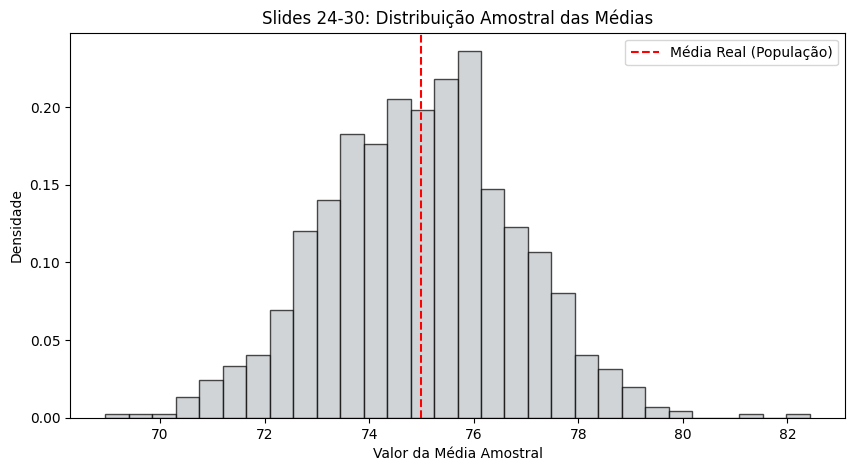

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

pop_mean = 75  #media real hipotética
pop_std = 10   #desvio padrao populacional
n = 30         #tamanho de cada amostra

#simulacao: coleta 1000 med9ias de amostras diferentes (Slide 30)
np.random.seed(42)
sample_means = [np.mean(np.random.normal(pop_mean, pop_std, n)) for _ in range(1000)]

plt.figure(figsize=(10, 5))
plt.hist(sample_means, bins=30, density=True, color='#bdc3c7', edgecolor='black', alpha=0.7)
plt.axvline(pop_mean, color='red', linestyle='--', label='Média Real (População)')
plt.title("Slides 24-30: Distribuição Amostral das Médias")
plt.xlabel("Valor da Média Amostral")
plt.ylabel("Densidade")
plt.legend()
plt.show()

### Slides 31 a 33 – O Erro Padrão (SE)
**Teoria:** Para quantificar o quão "espalhadas" estão as médias das amostras, usamos o **Erro Padrão**. Diferente do desvio padrão da população ($\sigma$), o SE descreve a precisão da nossa média amostral.

**Fórmula (Slide 31):**
$$SE = \frac{\sigma}{\sqrt{n}}$$

In [54]:
#implementacao da formula do slide 31
se = pop_std / np.sqrt(n)
print(f"Desvio Padrão (Sigma): {pop_std}")
print(f"Tamanho da Amostra (n): {n}")
print(f"Erro Padrão (SE) calculado: {se:.4f}")

Desvio Padrão (Sigma): 10
Tamanho da Amostra (n): 30
Erro Padrão (SE) calculado: 1.8257


### Slide 34 – Visualizando o Processo de Confiança
**Teoria:** Um intervalo de confiança de 95% não significa que há 95% de chance de a média estar lá, mas que o **processo** de construção gera intervalos que capturam a média real 95% das vezes. O slide mostra que, em 20 tentativas, esperamos que 1 falhe (cor laranja).

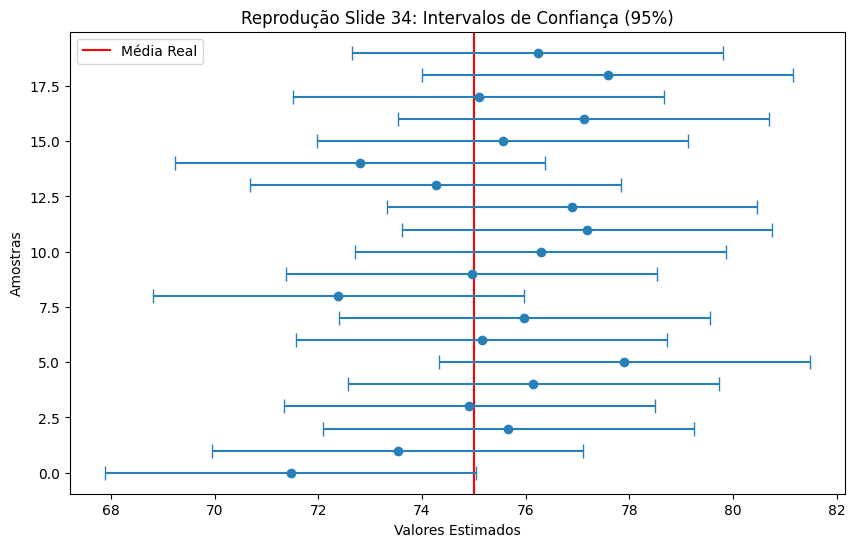

In [55]:
#reproducao do grafico do slide 34
n_samples = 20
z_95 = 1.96

plt.figure(figsize=(10, 6))
plt.axvline(pop_mean, color='red', linestyle='-', label='Média Real')

for i in range(n_samples):
    sample = np.random.normal(pop_mean, pop_std, n)
    m = np.mean(sample)
    margem = z_95 * (pop_std / np.sqrt(n))
    
    #verifica se o intervalo tem a media (slide 34)
    if (m - margem) <= pop_mean <= (m + margem):
        plt.errorbar(m, i, xerr=margem, fmt='o', color='#2980b9', capsize=5)
    else:
        plt.errorbar(m, i, xerr=margem, fmt='o', color='#e67e22', capsize=5)

plt.title("Reprodução Slide 34: Intervalos de Confiança (95%)")
plt.xlabel("Valores Estimados")
plt.ylabel("Amostras")
plt.legend()
plt.show()

### Slide 35 – Cálculo do Intervalo de 95%
**Teoria:** Para 95% de confiança, usamos o multiplicador **Z = 1.96**. 
**Exemplo numérico do slide:** Média Amostral = 79, SE = 2.5.
$$IC = 79 \pm (1.96 \times 2.5)$$

In [56]:
#dados do exemplo do slide 35
media_slide = 79
se_slide = 2.5
z = 1.96

lim_inf = media_slide - (z * se_slide)
lim_sup = media_slide + (z * se_slide)

print(f"Média: {media_slide}")
print(f"Margem de Erro: {z * se_slide}")
print(f"Intervalo de Confiança (Slide 35): [{lim_inf:.2f} a {lim_sup:.2f}]")

Média: 79
Margem de Erro: 4.9
Intervalo de Confiança (Slide 35): [74.10 a 83.90]


### Slides 36 a 39 – Largura vs. Confiança
**Teoria:** Se quisermos mais confiança (99%), o intervalo fica mais largo. Se aceitarmos menos confiança (90%), o intervalo fica mais estreito.
* 90% -> Z = 1.645
* 99% -> Z = 2.576

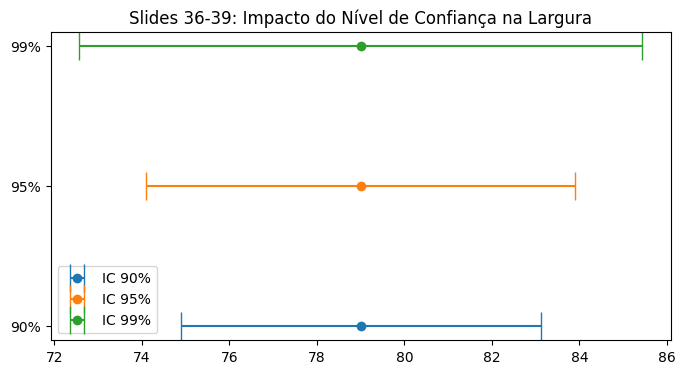

In [57]:
#comparacao conforme estap nos slides 38-39
confiancas = [0.90, 0.95, 0.99]
zs = [1.645, 1.96, 2.576]

plt.figure(figsize=(8, 4))
for i, (c, z_val) in enumerate(zip(confiancas, zs)):
    margem = z_val * se_slide
    plt.errorbar(media_slide, i, xerr=margem, fmt='o', capsize=10, label=f'IC {int(c*100)}%')

plt.yticks(range(3), ['90%', '95%', '99%'])
plt.title("Slides 36-39: Impacto do Nível de Confiança na Largura")
plt.legend()
plt.show()

### Slides 40 a 46 – Precisão e Tamanho da Amostra
**Teoria:** A precisão (largura do intervalo) é controlada pelo tamanho da amostra ($n$). Como $n$ está no denominador da fórmula do SE, amostras maiores produzem intervalos mais estreitos e estimativas mais precisas.

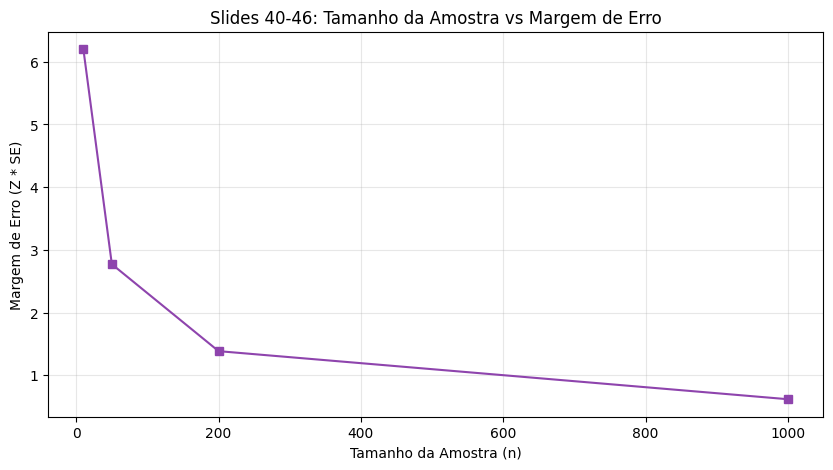

Fórmula Unificada (Slide 46): IC = Média +/- Z * (Sigma / sqrt(n))


In [58]:
#demonstacao dos slides 40-45
tamanhos_n = [10, 50, 200, 1000]
margens = [1.96 * (pop_std / np.sqrt(n_val)) for n_val in tamanhos_n]

plt.figure(figsize=(10, 5))
plt.plot(tamanhos_n, margens, marker='s', color='#8e44ad', linestyle='-')
plt.title("Slides 40-46: Tamanho da Amostra vs Margem de Erro")
plt.xlabel("Tamanho da Amostra (n)")
plt.ylabel("Margem de Erro (Z * SE)")
plt.grid(True, alpha=0.3)
plt.show()

#conclisao do slide 46
print("Fórmula Unificada (Slide 46): IC = Média +/- Z * (Sigma / sqrt(n))")

## 📐 F — Regressão Linear: Análise de Rotação e Métricas ($R^2$)

**Objetivo:** Reproduzir o exemplo do StatQuest (Tamanho do Rato vs Peso) e analisar como a variação da inclinação ($a$) afeta a qualidade do ajuste ($R^2$).

1.  **Regressão Linear (Scikit-Learn):** Utilizada para encontrar os parâmetros ótimos de $a$ (inclinação) e $b$ (intercepto).
2.  **Statsmodels:** Utilizado para obter o sumário estatístico detalhado (p-values, intervalos de confiança dos coeficientes).
3.  **Rotação:** Mantendo o intercepto $b$ fixo, variamos o coeficiente $a$ para provar que a reta calculada pelos Mínimos Quadrados é a que maximiza o $R^2$.

--- SUMÁRIO STATSMODELS ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.774
Model:                            OLS   Adj. R-squared:                  0.698
Method:                 Least Squares   F-statistic:                     10.25
Date:                Sat, 31 Jan 2026   Prob (F-statistic):             0.0493
Time:                        14:51:30   Log-Likelihood:                -3.0793
No. Observations:                   5   AIC:                             10.16
Df Residuals:                       3   BIC:                             9.377
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1348   

c:\Users\Francisco\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


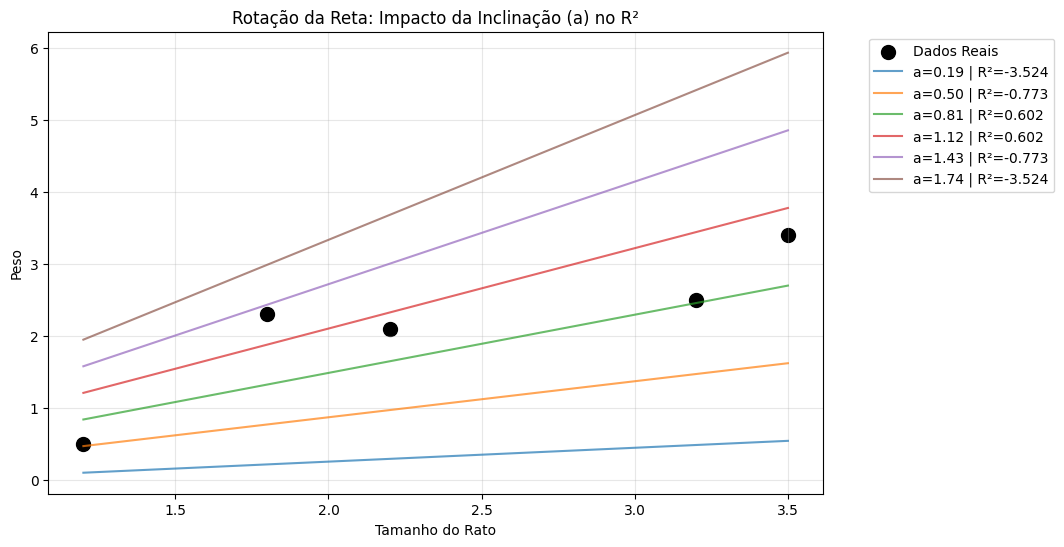


Melhor R² obtido (Sklearn): 0.7736 com a = 0.9642


In [61]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.metrics import r2_score

# 1. Dados do Exemplo (Slide StatQuest)
tamanho_rato = np.array([1.2, 1.8, 2.2, 3.2, 3.5]).reshape(-1, 1)
peso_rato = np.array([0.5, 2.3, 2.1, 2.5, 3.4])

# 2. Regressão com Scikit-Learn (Melhor Ajuste)
modelo_sk = LinearRegression()
modelo_sk.fit(tamanho_rato, peso_rato)
a_otimo = modelo_sk.coef_[0]
b_fixo = modelo_sk.intercept_
r2_otimo = modelo_sk.score(tamanho_rato, peso_rato)

# 3. Estatísticas com Statsmodels
X_stat = sm.add_constant(tamanho_rato) # Adiciona o intercepto
modelo_sm = sm.OLS(peso_rato, X_stat).fit()
print("--- SUMÁRIO STATSMODELS ---")
print(modelo_sm.summary())

# 4. Gerando 6 diferentes 'a's (rotações) a partir do 'a' ótimo
variacao_a = np.linspace(a_otimo * 0.2, a_otimo * 1.8, 6)

# 5. Plotagem das Retas e Cálculo de R2
plt.figure(figsize=(10, 6))
plt.scatter(tamanho_rato, peso_rato, color='black', s=100, label='Dados Reais')

for a in variacao_a:
    y_pred = a * tamanho_rato.flatten() + b_fixo
    r2_atual = r2_score(peso_rato, y_pred)
    
    # Destaca a melhor reta
    label_text = f'a={a:.2f} | R²={r2_atual:.3f}'
    plt.plot(tamanho_rato, y_pred, label=label_text, alpha=0.7)

plt.title("Rotação da Reta: Impacto da Inclinação (a) no R²")
plt.xlabel("Tamanho do Rato")
plt.ylabel("Peso")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nMelhor R² obtido (Sklearn): {r2_otimo:.4f} com a = {a_otimo:.4f}")

## 📘 Métodos Numéricos (Ruggiero & Lopes)

### G — Fatoração LU com Pivoteamento Parcial
Utiliza a troca de linhas (matriz de permutação $P$) para garantir que o pivô seja sempre o maior elemento em valor absoluto da coluna, evitando instabilidade numérica.

### H — Método de Gauss-Jacobi
Baseia-se no **Teorema 4 (Critério das Linhas)**. A convergência é garantida se a matriz for estritamente diagonal dominante.

### I — Método de Gauss-Seidel
Utiliza os valores atualizados das variáveis assim que são calculados.
* **Critério de Sassenfeld:** Uma condição necessária e suficiente de convergência mais poderosa que o critério de linhas. Se $\beta_{max} < 1$, o método converge independentemente da estimativa inicial.

In [ ]:
#pegta as paginas 146-147 e resolve o exemplo 7

def lu_pivoting(A):
    n = len(A)
    P = np.eye(n)
    L = np.eye(n)
    U = A.copy().astype(float)
    
    for i in range(n):
        #pivoteamento
        pivot_idx = np.argmax(np.abs(U[i:, i])) + i
        if pivot_idx != i:
            U[[i, pivot_idx]] = U[[pivot_idx, i]]
            P[[i, pivot_idx]] = P[[pivot_idx, i]]
            if i > 0:
                L[[i, pivot_idx], :i] = L[[pivot_idx, i], :i]
        
        #ELIMINACAO
        for j in range(i+1, n):
            factor = U[j, i] / U[i, i]
            L[j, i] = factor
            U[j, i:] -= factor * U[i, i:]
            
    return P, L, U

#ECEMPLO 7
A_ex7 = np.array([[3, 2, 4], [1, 1, 2], [4, 3, -2]])
P, L, U = lu_pivoting(A_ex7)

print("Matriz P:\n", P)
print("Matriz L:\n", L)
print("Matriz U:\n", U)

Matriz P:
 [[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]
Matriz L:
 [[ 1.    0.    0.  ]
 [ 0.25  1.    0.  ]
 [ 0.75 -1.    1.  ]]
Matriz U:
 [[ 4.    3.   -2.  ]
 [ 0.    0.25  2.5 ]
 [ 0.    0.    8.  ]]


In [64]:
#pega o teorema 4 da pagina 160 (criterio das linhas) e aplica no exemplo 10 (pag 157)

def gauss_jacobi(A, b, x0, tol=1e-4, max_iter=100):
    n = len(A)
    x = x0.copy().astype(float)
    #verificacao do criterio de linhas
    for i in range(n):
        soma = sum(abs(A[i, j]) for j in range(n) if i != j)
        if soma / abs(A[i, i]) >= 1:
            print(f"Aviso: Critério de linhas não satisfeito na linha {i}")

    for k in range(max_iter):
        x_new = np.zeros_like(x)
        for i in range(n):
            soma = sum(A[i, j] * x[j] for j in range(n) if i != j)
            x_new[i] = (b[i] - soma) / A[i, i]
        
        if np.linalg.norm(x_new - x, np.inf) < tol:
            return x_new, k+1
        x = x_new
    return x, max_iter

#exemplo 10
A_ex10 = np.array([[10, 2, 1], [1, 5, 1], [2, 3, 10]])
b_ex10 = np.array([7, -8, 6])
x_sol, iters = gauss_jacobi(A_ex10, b_ex10, np.zeros(3))
print(f"Solução Gauss-Jacobi em {iters} iterações: {x_sol}")

Solução Gauss-Jacobi em 10 iterações: [ 1.00001027 -1.99998396  1.00001466]


In [65]:
#implementa Critério de Sassenfeld (pág. 170), Critério de linhas (pág. 176) e aplica no exemplo 14 (pag 162)

def sassenfeld_beta(A):
    n = len(A)
    betas = np.zeros(n)
    for i in range(n):
        soma_1 = sum(abs(A[i, j]) * betas[j] for j in range(i))
        soma_2 = sum(abs(A[i, j]) for j in range(i + 1, n))
        betas[i] = (soma_1 + soma_2) / abs(A[i, i])
    return max(betas)

#exemplo 14
A_ex14 = np.array([[5, 1, 1], [3, 4, 1], [3, 3, 6]])
b_ex14 = np.array([5, 6, 0])

beta_max = sassenfeld_beta(A_ex14)
print(f"Beta máximo (Sassenfeld): {beta_max:.4f}")

def gauss_seidel(A, b, x0, tol=1e-4, max_iter=100):
    n = len(A)
    x = x0.copy().astype(float)
    for k in range(max_iter):
        x_old = x.copy()
        for i in range(n):
            soma = sum(A[i, j] * x[j] for j in range(n) if i != j)
            x[i] = (b[i] - soma) / A[i, i]
        if np.linalg.norm(x - x_old, np.inf) < tol:
            return x, k+1
    return x, max_iter

x_gs, iters_gs = gauss_seidel(A_ex14, b_ex14, np.zeros(3))
print(f"Solução Gauss-Seidel em {iters_gs} iterações: {x_gs}")

Beta máximo (Sassenfeld): 0.5500
Solução Gauss-Seidel em 7 iterações: [ 1.00000731  0.99999772 -1.00000252]
